In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
#scaling, normalization
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_extraction.text import CountVectorizer

#kmeans, dbscan, hierarchical (sklearn)
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
#evaluation
from sklearn.metrics import silhouette_score
#import dataset
from sklearn.datasets import load_iris

from sklearn.neighbors import kneighbors_graph

#distance matrix (dbscan elbow, hierarchical)
from scipy.spatial.distance import pdist, squareform

# hierarchical (scipy)
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

import pycountry
from collections import Counter
import ast

from scipy.stats import pearsonr
from sklearn.cluster import DBSCAN
!pip install -q kneed
from kneed import KneeLocator

from sklearn.cluster import OPTICS, cluster_optics_dbscan
from sklearn.neighbors import kneighbors_graph
from sklearn.decomposition import PCA


In [2]:
df = pd.read_csv("train_clustering.csv")

In [3]:
numerical = ['rating','startYear',  'runtimeMinutes','awardWins', 
                     'numVotes', 'totalImages', 'totalVideos', 'totalCredits','criticReviewsTotal', 'awardNominationsExcludeWins', 'numRegions', 
                      'userReviewsTotal']

bool_vars = ['canHaveEpisodes', 'isAdult']
categorical = ['titleType', 'countryOfOrigin', 'genres']

In [4]:
df_numeric = df[numerical]

In [5]:
from sklearn.cluster import KMeans

df_kmeans = df_numeric

X = df_kmeans.values


In [ ]:
# z-score, fit and then transform
scaler = StandardScaler()
scaler.fit(X)
X_scal = scaler.transform(X)

In [7]:
X_scal_df = pd.DataFrame(X_scal, columns=df_kmeans.columns)  

In [8]:
X_scal_df.head()

,rating,startYear,runtimeMinutes,awardWins,numVotes,totalImages,totalVideos,totalCredits,criticReviewsTotal,awardNominationsExcludeWins,numRegions,userReviewsTotal
0,0.608820,0.120129,-0.464457,-0.169800,-0.034351,-0.140546,-0.112764,-0.326365,-0.115799,-0.149939,-0.435571,-0.139360
1,-0.833154,-0.377551,-0.770154,-0.169800,-0.073492,-0.140546,-0.112764,-0.493433,-0.181675,-0.149939,-0.435571,-0.139360
2,-0.833154,0.005280,0.809284,-0.169800,-0.072116,-0.140546,-0.112764,-0.301305,-0.181675,-0.149939,-0.435571,-0.119053
3,-0.833154,1.115491,-0.693730,-0.169800,-0.073288,0.144153,-0.112764,-0.033995,-0.181675,-0.149939,-0.435571,-0.139360
4,0.608820,1.077207,0.554536,0.258692,0.727008,4.550200,0.807672,-0.109176,0.081828,0.128083,4.872487,9.039247


In [9]:
X_scal_df.describe().T

,count,mean,std,min,25%,50%,75%,max
rating,16423.0,-5.310791e-17,1.00003,-4.438088,-0.833154,-0.112167,0.608820,2.050793
startYear,16423.0,5.145302e-16,1.00003,-4.358997,-0.530684,0.196696,0.809226,1.230340
runtimeMinutes,16423.0,6.424867e-17,1.00003,-1.457974,-0.744679,-0.209708,0.809284,13.801437
awardWins,16423.0,-4.056103e-18,1.00003,-0.169800,-0.169800,-0.169800,-0.169800,35.395078
numVotes,16423.0,1.946929e-18,1.00003,-0.073797,-0.073288,-0.072218,-0.066510,49.186452
totalImages,16423.0,-1.859047e-18,1.00003,-0.154103,-0.140546,-0.140546,-0.072761,47.349868
totalVideos,16423.0,-1.054587e-18,1.00003,-0.112764,-0.112764,-0.112764,-0.112764,62.016618
totalCredits,16423.0,3.125903e-17,1.00003,-0.501787,-0.368132,-0.217770,0.041186,41.039787
criticReviewsTotal,16423.0,9.829290e-18,1.00003,-0.181675,-0.181675,-0.181675,-0.115799,34.930117
awardNominationsExcludeWins,16423.0,7.084660e-18,1.00003,-0.149939,-0.149939,-0.149939,-0.149939,34.324784


In [10]:
print(X_scal_df.shape)


(16423, 12)


In [11]:
F = X_scal_df


In [12]:
print(F.shape)


(16423, 12)


In [13]:
def sse_elbow(X_scal_df, max_clusters):
    sse = []  # List to store SSE for each cluster count
    cluster_range = range(1, max_clusters + 1)

    # Compute SSE for each k
    for k in cluster_range:
        kmeans = KMeans(n_clusters=k, n_init=10, max_iter=100, random_state=42)
        kmeans.fit(X_scal_df)
        sse.append(kmeans.inertia_)

    # Determine the elbow point
    kl = KneeLocator(cluster_range, sse, curve="convex", direction="decreasing")
    elbow_point = kl.elbow

    # Plot the SSE values and mark the elbow point
    plt.figure(figsize=(8, 4))
    plt.plot(cluster_range, sse, marker='o', label='SSE')
    plt.axvline(x=elbow_point, color='r', linestyle='--', label=f'Elbow Point: {elbow_point}')
    plt.xticks(cluster_range)
    plt.xlabel("Number of Clusters")
    plt.ylabel("SSE")
    plt.title("Elbow Method for Optimal k")
    plt.legend()
    plt.show()

    return elbow_point
    
def sil_k_choice(X_scal_df , max_clusters):
  # Precompute pairwise distances
    dist_matrix = squareform(pdist(X_scal_df ))

    sil_scores = []  # List to store silhouette scores
    cluster_range = range(2, max_clusters + 1)

    # Compute silhouette score for each k
    for k in cluster_range:
        kmeans = KMeans(n_clusters=k, n_init=10, max_iter=100, random_state=42)
        labels = kmeans.fit_predict(X_scal_df)
        sil_score = silhouette_score(dist_matrix, labels, metric='precomputed')
        sil_scores.append(sil_score)

    # Find the second-highest silhouette peak
    sorted_sil_scores = sorted(enumerate(sil_scores, start=2), key=lambda x: x[1], reverse=True)
    #sil_peak_k=sil_scores.index(max(sil_scores))+2
    sil_peak_k = sorted_sil_scores[1][0] if len(sorted_sil_scores) > 1 else None

    # Plot the silhouette scores
    plt.figure(figsize=(8, 4))
    plt.plot(cluster_range, sil_scores, marker='o', label='Silhouette Score')
    plt.xticks(cluster_range)
    plt.xlabel("Number of Clusters")
    plt.ylabel("Silhouette Coefficient")
    plt.title("Silhouette Method for Optimal k")
    plt.axvline(x=sil_peak_k, color='g', linestyle='--', label=f'Second Peak: {sil_peak_k}')
    plt.legend()
    plt.show()

    return sil_peak_k

# KMEANS FULL

In [14]:
X = F.copy(deep = True)


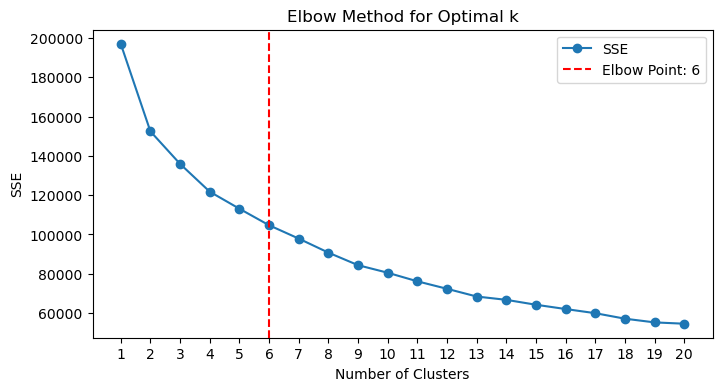

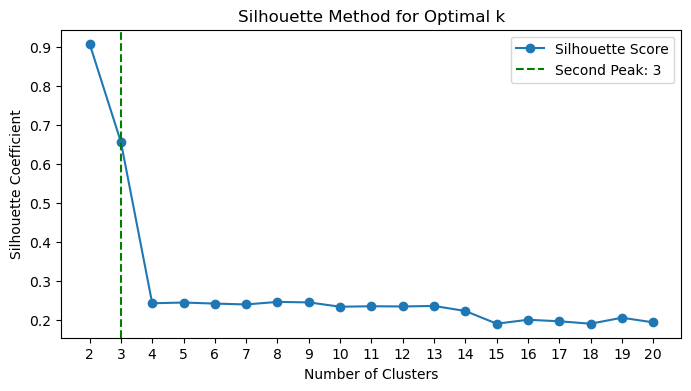

3

In [15]:
sse_elbow(X, 20)
sil_k_choice(X, 20)

In [16]:
for k in range(3, 7):
  print("k = ", k)
  kmeans = KMeans(init='k-means++', n_clusters=k, n_init=10, max_iter=100)
  kmeans.fit(X)
  print('labels', np.unique(kmeans.labels_, return_counts=True))
  print('sse', kmeans.inertia_)
  print('silhouette', silhouette_score(X, kmeans.labels_))

k =  3
labels (array([0, 1, 2]), array([15663,    53,   707], dtype=int64))
sse 135985.6517928004
silhouette 0.6353196896066546
k =  4
labels (array([0, 1, 2, 3]), array([ 467, 6400,   45, 9511], dtype=int64))
sse 121770.06284462479
silhouette 0.24340816539978596
k =  5
labels (array([0, 1, 2, 3, 4]), array([6439, 9661,  290,   21,   12], dtype=int64))
sse 113051.51549285126
silhouette 0.24546031133193752
k =  6
labels (array([0, 1, 2, 3, 4, 5]), array([  64, 6235,   17,    7, 9378,  722], dtype=int64))
sse 104688.95783836344
silhouette 0.24261900380225868


In [17]:
kmeans = KMeans(init='k-means++', n_clusters=3, n_init=10, max_iter=100)
kmeans.fit(X)

KMeans(max_iter=100, n_clusters=3, n_init=10)

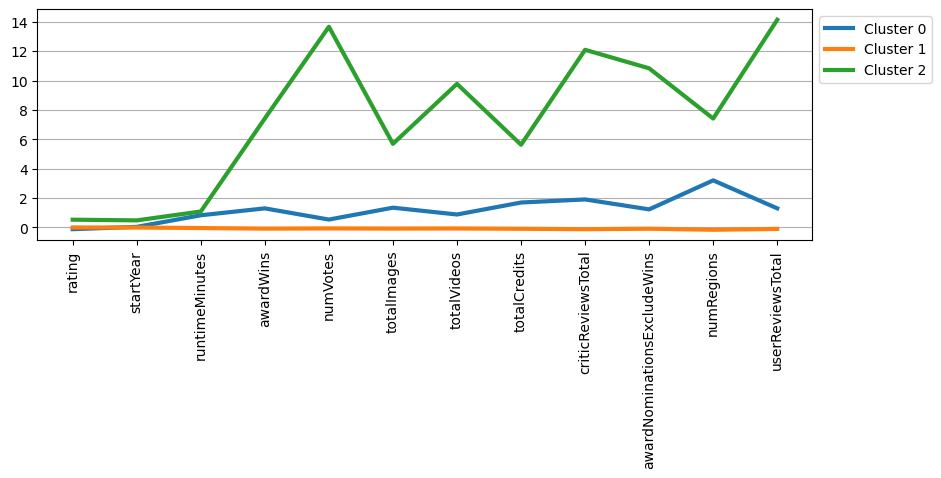

In [18]:
plt.figure(figsize=(10, 3))

for i in range(len(kmeans.cluster_centers_)):
    n_centroids = len(kmeans.cluster_centers_[i])
    plt.plot(range(0, n_centroids), kmeans.cluster_centers_[i], label='Cluster %s' % i, linewidth=3)
plt.xticks(range(0, n_centroids), list(X.columns))
plt.legend(bbox_to_anchor=(1,1))
plt.grid(axis='y')
plt.tick_params(axis='x', labelrotation=90)
plt.show()

### Bisecting K-means

In [19]:
from sklearn.cluster import BisectingKMeans

In [20]:
bkmeans = BisectingKMeans(n_clusters=3, n_init=10, max_iter=100, random_state=94)
bkmeans.fit(X_scal)

BisectingKMeans(max_iter=100, n_clusters=3, n_init=10, random_state=94)

In [21]:
centers = scaler.inverse_transform(bkmeans.cluster_centers_)
centers

array([[7.15217391e+00, 2.00297101e+03, 9.87536232e+01, 1.45507246e+01,
        2.10398536e+05, 4.59028986e+02, 1.83043478e+01, 7.61840580e+02,
        1.58333333e+02, 3.07826087e+01, 4.29710145e+01, 5.68318841e+02],
       [5.61246546e+00, 1.97968991e+03, 8.70955631e+01, 5.47212742e-01,
        1.15318918e+03, 1.52668617e+01, 2.88314643e-01, 6.53786771e+01,
        4.69364538e+00, 7.12823013e-01, 5.99821225e+00, 9.64683894e+00],
       [7.28139398e+00, 1.99912891e+03, 4.05480835e+01, 2.09489266e-01,
        2.20548280e+02, 5.98666797e+00, 9.67552201e-02, 5.21204784e+01,
        5.37888442e-01, 2.30075483e-01, 1.79668660e+00, 1.38574650e+00]])

In [22]:
print('SSE', bkmeans.inertia_)
print('Silhouette', silhouette_score(X_scal, bkmeans.labels_))

SSE 136755.33431718286
Silhouette 0.26020601474732225


# X-Means

# BDSCAN

In [23]:
X = F.copy(deep = True)

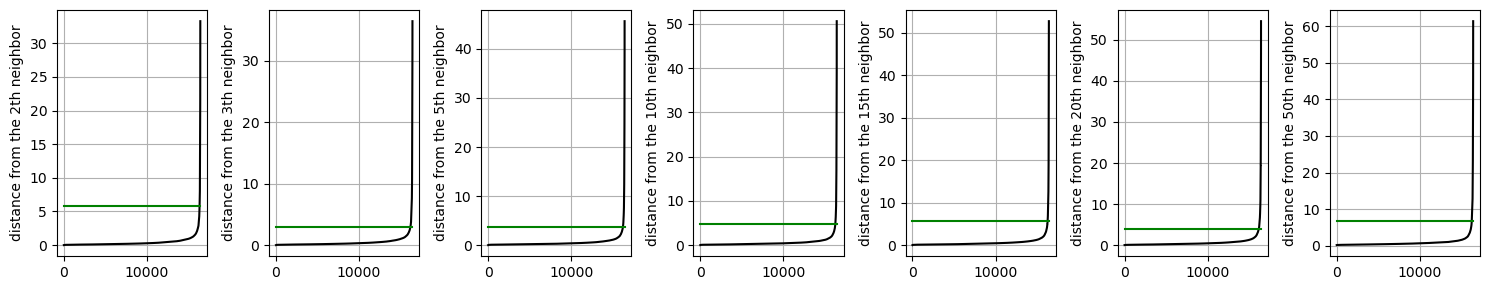

In [24]:
ks = [2, 3, 5, 10, 15, 20, 50]
X_eps = []


def eps_choice(df, ks, eps_list):
    dist = squareform(pdist(df, 'euclidean'))

    fig = plt.figure(figsize=(15, 3)) # dimensions of the overall plot
    fig_dims = (1, len(ks))

    for i in range(len(ks)):
        k = ks[i]
        kth_distances = []

        for d in dist:  # d is a vector containing distances between the ith record and all the others
            index_kth_distance = np.argsort(d)[k]  # take the index of the kth nearest neighbor
            kth_distances.append(d[index_kth_distance])  # store the distance in a list

        # Sort the distances
        kth_distances.sort()

        # Create an array of indices
        indices = np.arange(len(kth_distances))

        # Use the KneeLocator to find the elbow point
        knee_locator = KneeLocator(indices, kth_distances, curve='convex', direction='increasing')
        elbow_point = knee_locator.knee
        eps_list.append(round(kth_distances[elbow_point], 2))  # Round to 2 decimal places

        plt.subplot2grid(fig_dims, (0, i))
        plt.plot(indices, kth_distances, 'black')
        plt.plot([0, len(kth_distances)], [kth_distances[elbow_point], kth_distances[elbow_point]], 'g-')  # Plot the elbow point
        plt.ylabel('distance from the {}th neighbor'.format(k))
        plt.grid(True)  # This line adds a grid to the plot

    plt.tight_layout()
    plt.show()

eps_choice(X, ks, X_eps)

In [25]:
print(ks)
print(X_eps)

[2, 3, 5, 10, 15, 20, 50]
[5.86, 3.02, 3.78, 4.89, 5.71, 4.04, 6.66]


In [26]:
def dbscan_results(df, eps, ks):
  for i in range(len(eps)):
    db = DBSCAN(eps=eps[i], min_samples=ks[i]).fit(df)
    labels, counts = np.unique(db.labels_, return_counts=True)
    print(labels, counts)
    print(f"eps={eps[i]}, minPts={ks[i]} -> {len(labels)-1} clusters")
    for i in range(len(labels)):
      print(f"Cluster [{labels[i]}]: {counts[i]} samples")

    clustering_labels = db.fit_predict(df)
    df.loc[:, 'db_labels'] = clustering_labels
    if len(np.unique(db.labels_)) > 2:
        print('Silhouette (F)', silhouette_score(df[db.labels_ != -1], db.labels_[db.labels_ != -1]))
    else:
        print('Cannot calculate silhouette score with only one cluster')

    print("--------------------------------")

dbscan_results(df=X, eps=X_eps, ks=ks)

[-1  0  1  2  3  4  5  6] [   73 16335     2     2     3     3     2     3]
eps=5.86, minPts=2 -> 7 clusters
Cluster [-1]: 73 samples
Cluster [0]: 16335 samples
Cluster [1]: 2 samples
Cluster [2]: 2 samples
Cluster [3]: 3 samples
Cluster [4]: 3 samples
Cluster [5]: 2 samples
Cluster [6]: 3 samples
Silhouette (F) 0.8177483806761007
--------------------------------
[-1  0  1  2  3  4  5] [  187 16218     3     4     5     3     3]
eps=3.02, minPts=3 -> 6 clusters
Cluster [-1]: 187 samples
Cluster [0]: 16218 samples
Cluster [1]: 3 samples
Cluster [2]: 4 samples
Cluster [3]: 5 samples
Cluster [4]: 3 samples
Cluster [5]: 3 samples
Silhouette (F) 0.6612391426646707
--------------------------------
[-1  0  1] [  163 16255     5]
eps=3.78, minPts=5 -> 2 clusters
Cluster [-1]: 163 samples
Cluster [0]: 16255 samples
Cluster [1]: 5 samples
Silhouette (F) 0.7479255088309753
--------------------------------
[-1  0] [  124 16299]
eps=4.89, minPts=10 -> 1 clusters
Cluster [-1]: 124 samples
Cluster [0

In [27]:
dist = pdist(X, 'euclidean')
dist = squareform(dist)

k= 2

In [28]:
dbscan = DBSCAN(eps=5.86, min_samples=2, metric='precomputed')
dbscan.fit(dist)

DBSCAN(eps=5.86, metric='precomputed', min_samples=2)

In [29]:
np.unique(dbscan.labels_, return_counts=True)
print('Silhouette', silhouette_score(X_minmax[dbscan.labels_ != -1], dbscan.labels_[dbscan.labels_ != -1]))

NameError: name 'X_minmax' is not defined

# OPTICS

In [28]:
X = F.copy(deep = True)

In [ ]:
from sklearn.cluster import OPTICS, cluster_optics_dbscan

optics = OPTICS(min_samples = 50, max_eps = np.inf, min_cluster_size=50)
optics.fit(X)

if len(np.unique(optics.labels_ )) > 2:
  print("Silhouette F", silhouette_score(X[optics.labels_ != -1], optics.labels_[optics.labels_ != -1]))
else:
  print('Cannot calculate silhouette score with only one cluster')


Cannot calculate silhouette score with only one cluster


Text(0.5, 1.0, 'Reachability Plot')

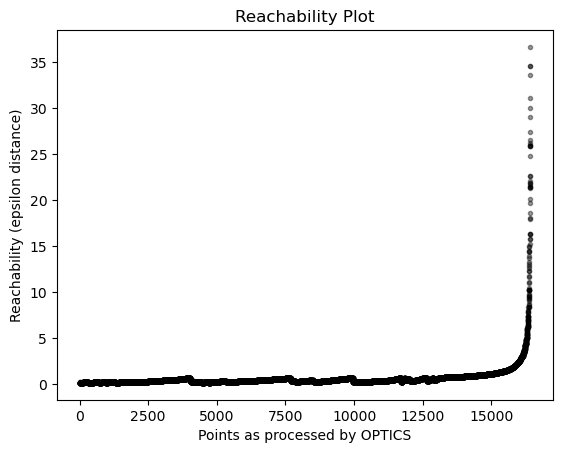

In [ ]:
# Valleys in the plot correspond to the clusters
space = np.arange(len(X))
reachability = optics.reachability_[optics.ordering_]
labels = optics.labels_[optics.ordering_]

# Reachability plot
plt.plot(space, reachability, "k.", alpha=0.4)
plt.xlabel("Points as processed by OPTICS")
plt.ylabel("Reachability (epsilon distance)")
# plt.axhline(0.3, c="red")
plt.title("Reachability Plot")